# Seasonal Agriculture Performance Analysis

## Introduction

Agricultural performance is influenced by seasonal variations in environmental conditions, farming practices, resource availability, and economic factors. As these conditions change across seasons, agricultural outcomes such as yield, production, resource consumption, and profitability may also vary.

This project analyzes agricultural data across different seasons to identify meaningful patterns, trends, relationships, and variations in agricultural performance. The analysis focuses on understanding how seasonal conditions are associated with agricultural outcomes, resource usage, environmental factors, and economic performance.

The analysis will involve data exploration, cleaning and preparation, statistical analysis, visualization, seasonal comparisons, and interpretation of key findings. The objective is to derive evidence-based insights that can support better understanding and planning of seasonal agricultural activities.

### Key Areas of Analysis
- Seasonal variation in agricultural performance
- Changes in environmental and farming conditions
- Resource usage and efficiency across seasons
- Relationships between seasonal conditions and agricultural outcomes
- Economic performance across seasons
- Regional and categorical differences
- Identification of unusual or significant patterns
- Data-driven conclusions and recommendations

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.shape

(4000, 28)

In [5]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct

In [6]:
# Data quality assessment
print("Duplicate Rows:", df.duplicated().sum())

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing Values:")
print(missing if len(missing) else "No missing values")

print("\nCategorical Variables:")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nSeason Distribution:")
print(df["Season"].value_counts())

print("\nNumerical Summary:")
display(df.describe().T.round(2))

Duplicate Rows: 0

Missing Values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Categorical Variables:
Farm_ID: 4000 unique values
State: 8 unique values
District: 10 unique values
Crop: 8 unique values
Season: 3 unique values
Irrigation_Method: 4 unique values

Season Distribution:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.0,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.0,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


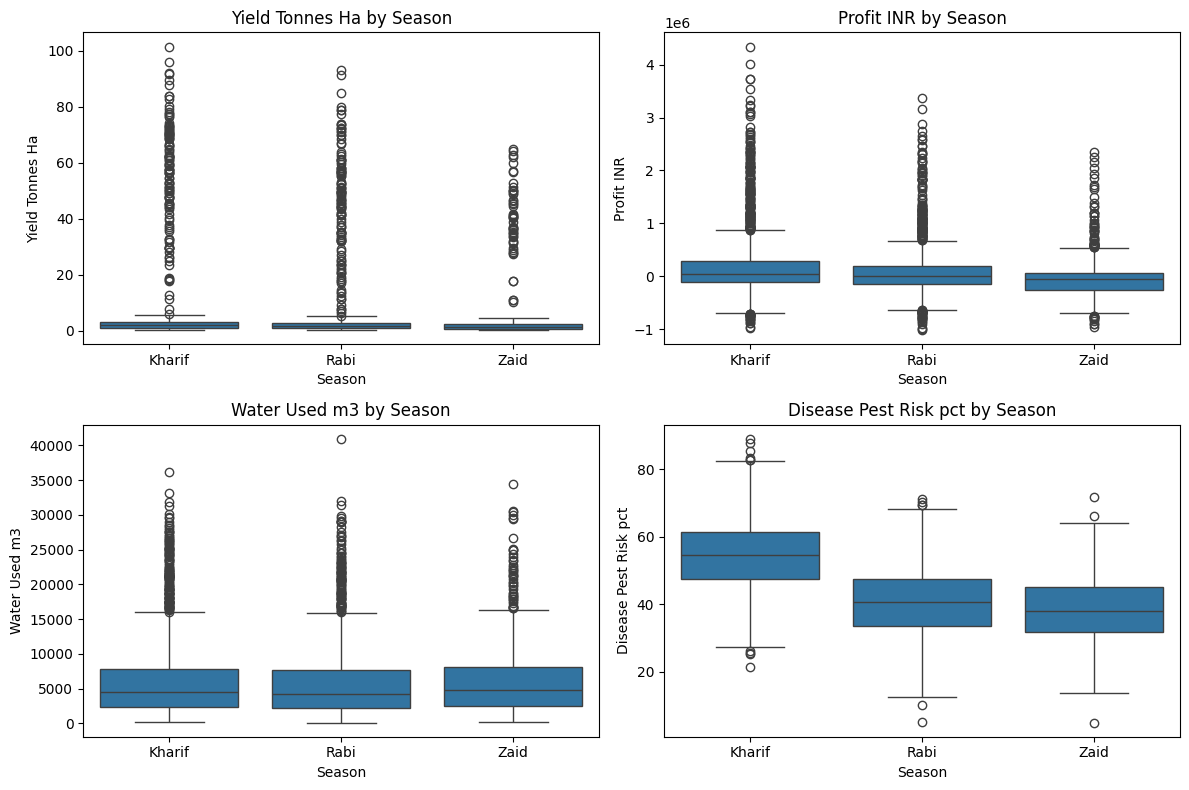

In [7]:
season_summary = df.groupby("Season").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)

# Visual comparison
metrics = ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Disease_Pest_Risk_pct"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, metrics):
    sns.boxplot(data=df, x="Season", y=metric, ax=ax)
    ax.set_title(f"{metric.replace('_', ' ')} by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel(metric.replace("_", " "))

plt.tight_layout()
plt.show()

## Initial Seasonal Findings

The initial seasonal comparison reveals clear differences in agricultural and economic performance:

- **Kharif** shows the highest average yield and production, along with the highest average revenue and profit, indicating the strongest overall performance among the three seasons.
- **Rabi** demonstrates moderate agricultural and economic performance, falling between Kharif and Zaid across most key indicators.
- **Zaid** records the lowest average yield and production and is the only season with a **negative average profit**, indicating comparatively weaker economic performance.
- Water consumption remains relatively high across all three seasons, with **Zaid showing the highest average water usage despite having the lowest yield and water-use efficiency**.
- **Disease and pest risk is highest during Kharif**, while Rabi and Zaid show comparatively lower average risk.
- The boxplots also indicate substantial variation and several extreme observations across seasons, suggesting that averages alone do not fully explain seasonal performance.

These initial observations provide a basis for further investigation into the environmental conditions, farming practices, resource usage, and regional or crop-level factors that may contribute to the observed seasonal differences.

Average Environmental & Soil Conditions by Season:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20,6.73,120.02,58.10,105.30
Rabi,436.00,23.49,57.89,7.59,24.05,6.67,120.40,57.31,103.93
Zaid,299.42,31.04,52.01,8.18,19.17,6.69,120.53,58.13,105.42


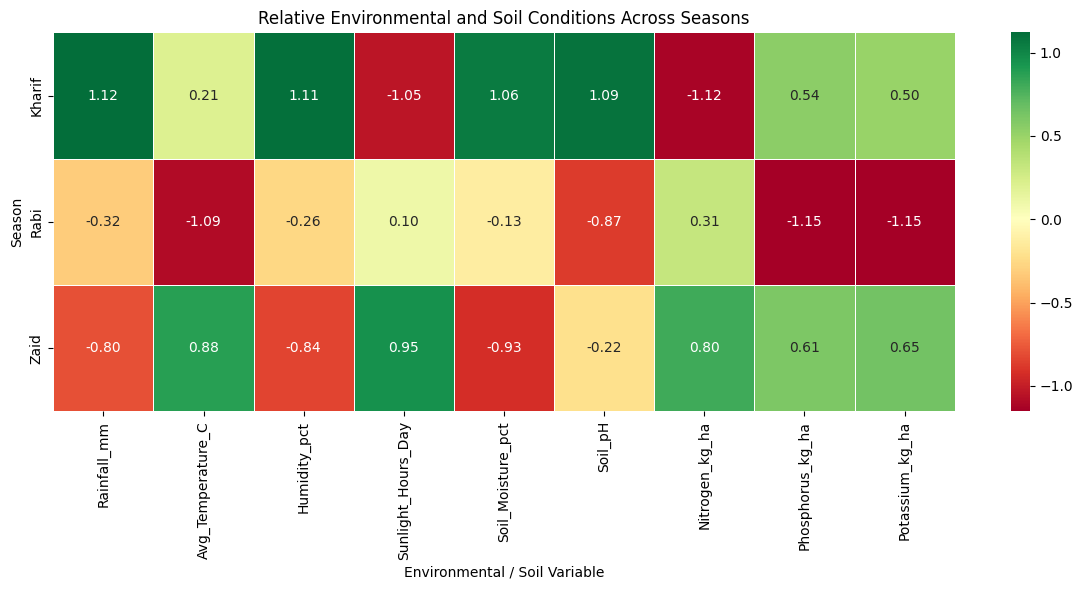

In [10]:
# Seasonal comparison of environmental and soil conditions

environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Soil_pH",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha"
]

environmental_summary = df.groupby("Season")[environmental_cols].mean().round(2)

print("Average Environmental & Soil Conditions by Season:")
display(environmental_summary)

# Standardized heatmap for comparison across variables
standardized = (environmental_summary - environmental_summary.mean()) / environmental_summary.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    standardized,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Relative Environmental and Soil Conditions Across Seasons")
plt.xlabel("Environmental / Soil Variable")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

## Environmental and Soil Conditions: Key Findings

The seasonal comparison reveals distinct environmental conditions across the three agricultural seasons. Kharif is characterized by substantially higher rainfall, humidity, and soil moisture, whereas Zaid experiences lower rainfall and humidity but higher temperature and sunlight exposure. Rabi generally exhibits intermediate environmental conditions.

In contrast, soil pH and the average nitrogen, phosphorus, and potassium levels remain relatively stable across seasons. This suggests that the major seasonal differences observed in agricultural performance may be more closely associated with environmental conditions and farming practices than with large variations in the measured soil nutrient levels.

These observations provide a basis for investigating whether environmental conditions such as rainfall, temperature, soil moisture, and sunlight are associated with differences in yield, resource efficiency, and economic performance.

Correlation of Environmental Variables with Yield:


,Correlation with Yield
Rainfall_mm,0.031
Soil_Moisture_pct,0.010
Avg_Temperature_C,0.009
Sunlight_Hours_Day,-0.015


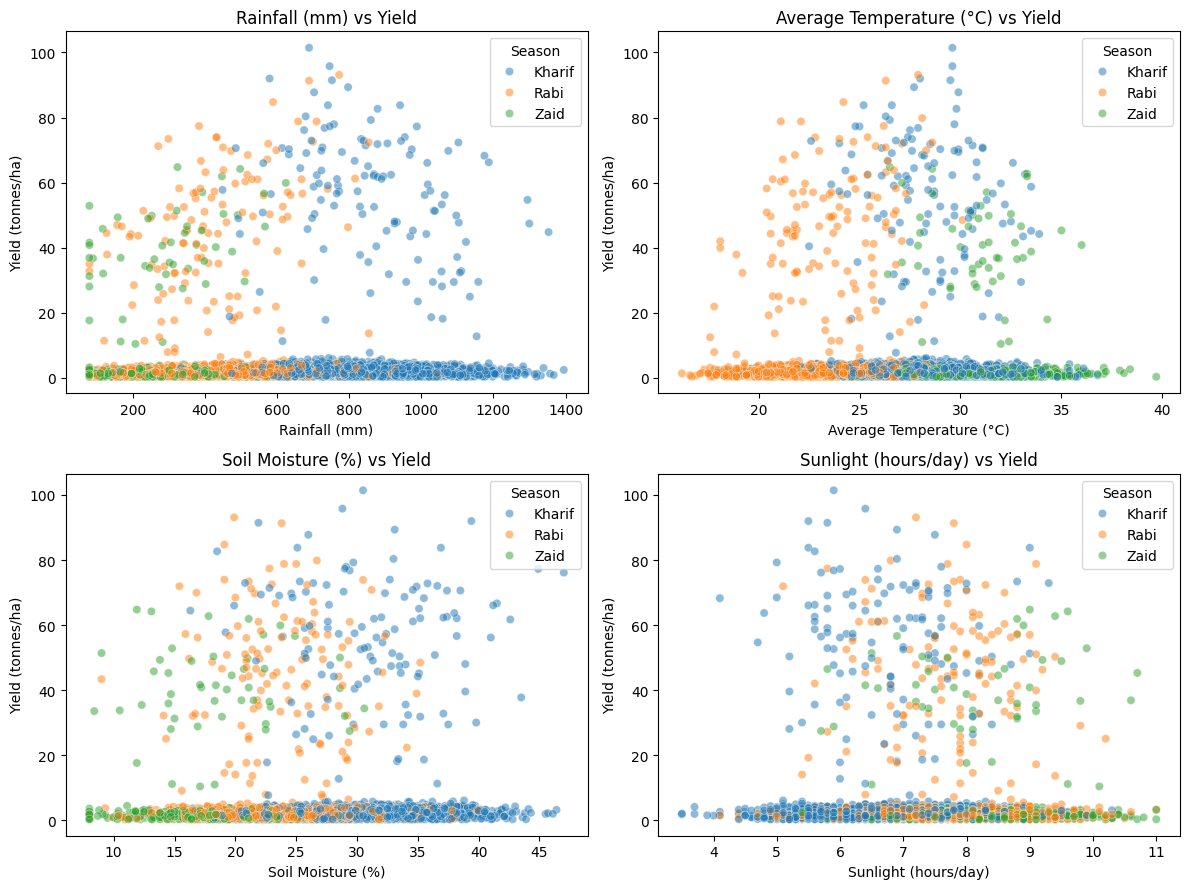

In [11]:
# Environmental conditions vs agricultural performance

relationship_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Sunlight_Hours_Day",
    "Yield_Tonnes_Ha"
]

# Correlation analysis
correlation = df[relationship_cols].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha")
correlation = correlation.sort_values(ascending=False)

print("Correlation of Environmental Variables with Yield:")
display(correlation.round(3).to_frame("Correlation with Yield"))

# Scatter plots by season
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

variables = [
    ("Rainfall_mm", "Rainfall (mm)"),
    ("Avg_Temperature_C", "Average Temperature (°C)"),
    ("Soil_Moisture_pct", "Soil Moisture (%)"),
    ("Sunlight_Hours_Day", "Sunlight (hours/day)")
]

for ax, (col, label) in zip(axes.flat, variables):
    sns.scatterplot(
        data=df,
        x=col,
        y="Yield_Tonnes_Ha",
        hue="Season",
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"{label} vs Yield")
    ax.set_xlabel(label)
    ax.set_ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

## Environmental Conditions vs Yield: Key Findings

The correlation analysis shows that rainfall, soil moisture, temperature, and sunlight have very weak linear relationships with yield, with correlation coefficients ranging from -0.015 to 0.031.

The scatter plots further indicate substantial variation in yield across different environmental conditions. Therefore, the observed seasonal differences in yield cannot be explained by any single environmental variable in isolation.

This suggests that agricultural performance may depend on a combination of factors, including farming practices, resource usage, crop characteristics, and regional conditions. Further analysis is therefore required to identify the factors that may better explain variations in agricultural performance.

> **Note:** Correlation indicates association and does not establish causation.

Season-wise Correlation of Environmental Variables with Yield:


,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Sunlight_Hours_Day
Kharif,-0.019,-0.011,0.001,-0.021
Rabi,0.042,0.054,-0.021,0.009
Zaid,0.049,-0.045,-0.028,0.022


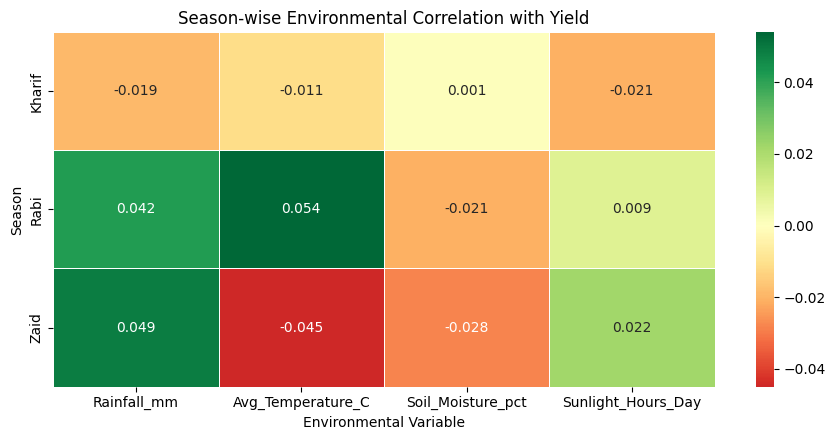

In [12]:
# Season-wise correlation between environmental conditions and yield

environmental_vars = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Sunlight_Hours_Day"
]

season_correlations = {}

for season in df["Season"].unique():
    corr = (
        df[df["Season"] == season][environmental_vars + ["Yield_Tonnes_Ha"]]
        .corr()["Yield_Tonnes_Ha"]
        .drop("Yield_Tonnes_Ha")
    )
    season_correlations[season] = corr

season_corr_df = pd.DataFrame(season_correlations).T.round(3)

print("Season-wise Correlation of Environmental Variables with Yield:")
display(season_corr_df)

# Heatmap
plt.figure(figsize=(9, 4.5))
sns.heatmap(
    season_corr_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Season-wise Environmental Correlation with Yield")
plt.xlabel("Environmental Variable")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

## Season-wise Environmental Relationships

Season-wise correlation analysis confirms that the environmental variables examined do not show meaningful linear relationships with yield within any of the three seasons. All correlation coefficients remain very close to zero, with the strongest observed relationship being only 0.054 between temperature and yield during Rabi.

This indicates that the seasonal differences in agricultural performance cannot be adequately explained by rainfall, temperature, soil moisture, or sunlight alone. The results reinforce the need to examine other factors such as farming practices, resource utilization, crop characteristics, and regional conditions.

Therefore, environmental conditions will be considered as part of the broader agricultural context rather than as individual predictors of yield.

Average Farming Practices & Resource Usage by Season:


,Farm_Area_Hectares,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Seed_Quality_Score
Season,,,,,,
Kharif,7.94,187.08,5.08,6102.20,5.89,0.82
Rabi,7.75,185.41,5.02,5846.99,5.19,0.83
Zaid,8.09,184.64,5.17,6419.89,4.41,0.82



Irrigation Method by Season (%):


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


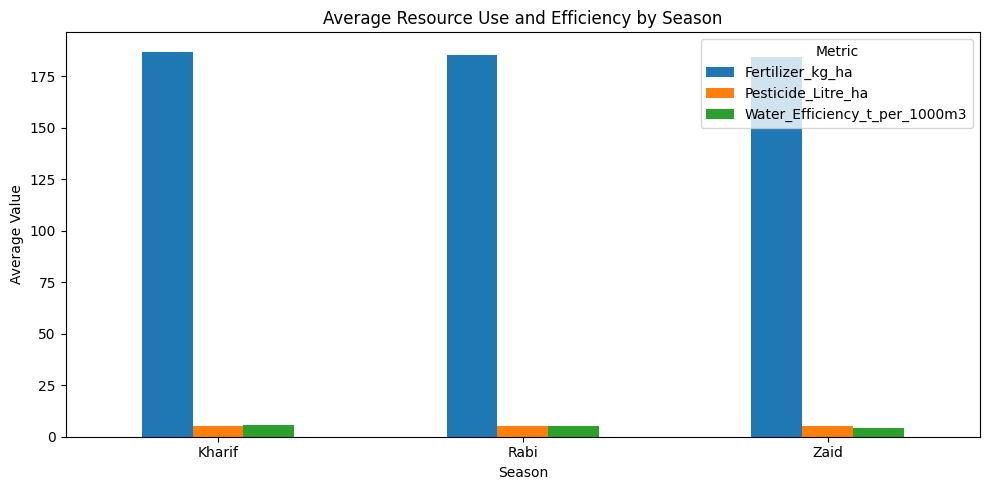

In [9]:
# Seasonal comparison of farming practices and resource usage

resource_cols = [
    "Farm_Area_Hectares",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Seed_Quality_Score"
]

resource_summary = df.groupby("Season")[resource_cols].mean().round(2)

print("Average Farming Practices & Resource Usage by Season:")
display(resource_summary)

print("\nIrrigation Method by Season (%):")
irrigation_share = pd.crosstab(
    df["Season"], df["Irrigation_Method"], normalize="index"
).mul(100).round(1)
display(irrigation_share)

# Visual comparison
resource_plot = df.groupby("Season")[[
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Efficiency_t_per_1000m3"
]].mean()

resource_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Average Resource Use and Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Farming Practices and Resource Usage: Key Findings

The seasonal comparison shows that farming practices and resource inputs are broadly similar across the three seasons. Fertilizer usage, pesticide application, farm area, and seed quality show only minor seasonal differences.

However, **Zaid records the highest average water consumption (6,419.89 m³) and the lowest water-use efficiency (4.41 tonnes per 1,000 m³)**. Kharif, in comparison, achieves the highest water-use efficiency at 5.89 tonnes per 1,000 m³.

Irrigation methods are also relatively consistent across seasons, with flood irrigation being the most common method. Therefore, major differences in resource inputs alone do not appear sufficient to explain the seasonal variation in agricultural performance.

The comparatively low water-use efficiency of Zaid warrants further investigation alongside its lower yield and negative average profit.

In [10]:
# Crop and regional seasonal comparison

crop_season = df.groupby(["Crop", "Season"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).round(2)

print("Crop-wise Seasonal Performance:")
display(crop_season)

# Overall crop performance
crop_summary = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean")
).sort_values("Avg_Profit", ascending=False).round(2)

print("\nOverall Crop Performance:")
display(crop_summary)

# Regional seasonal performance
region_season = df.groupby(["State", "Season"])["Profit_INR"].mean().unstack().round(2)

print("\nAverage Profit by State and Season:")
display(region_season)

Crop-wise Seasonal Performance:


Avg_Yield  Avg_Profit
Crop      Season                       
Chilli    Kharif       1.73   954380.42
          Rabi         1.46   638572.50
          Zaid         1.18   448659.09
Cotton    Kharif       1.37   216999.55
          Rabi         1.19   107343.59
          Zaid         0.95   -53925.34
Groundnut Kharif       1.48   108265.44
          Rabi         1.22    10416.54
          Zaid         1.04   -68872.50
Maize     Kharif       2.97   -39332.67
          Rabi         2.61   -89133.40
          Zaid         2.30  -194049.17
Pulses    Kharif       1.04    43338.90
          Rabi         0.87   -14309.14
          Zaid         0.65  -139227.81
Rice      Kharif       2.71   -64903.40
          Rabi         2.33   -98427.87
          Zaid         1.90  -227239.34
Sugarcane Kharif      53.46  1000790.81
          Rabi        43.94   731612.86
          Zaid        38.42   583635.80
Wheat     Kharif       2.26  -105871.87
          Rabi         2.06  -119954.57
          Zaid         1.75  -193208.95


Overall Crop Performance:


,Avg_Yield,Avg_Profit,Avg_Revenue
Crop,,,
Sugarcane,46.94,817187.99,1371980.11
Chilli,1.54,750878.34,1276777.23
Cotton,1.23,124546.92,639423.08
Groundnut,1.32,44858.12,542935.50
Pulses,0.92,-4238.05,528465.87
Maize,2.72,-83978.33,457067.99
Rice,2.44,-102213.50,423615.26
Wheat,2.11,-123398.34,400104.89



Average Profit by State and Season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


## Crop and Regional Analysis: Key Findings

The crop-wise analysis reveals a consistent seasonal pattern: average yield declines from Kharif to Rabi and further to Zaid across every crop category. This indicates that the seasonal variation in agricultural performance is not restricted to a particular crop.

Economic performance shows a similar pattern. Kharif records the highest average profit for every crop, while Zaid records the lowest. Sugarcane and Chilli emerge as the strongest-performing crops in terms of average profitability, whereas Maize, Rice, Wheat, and Pulses show negative average profits overall.

Regional analysis further shows that Kharif remains profitable across all states in the dataset. Rabi also records positive average profit across all states, while Zaid shows considerable regional variation, with only a few states maintaining positive average profitability.

Overall, the results suggest that seasonal effects on agricultural performance are broadly consistent across crops, but regional conditions can influence the magnitude and direction of economic outcomes, particularly during Zaid.

Economic Performance by Season:


,Avg_Revenue,Avg_Cost,Avg_Profit
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82



Profit Margin by Season:


,Avg_Profit,Profit_Margin_%
Season,,
Kharif,178914.65,25.17
Rabi,87689.47,14.58
Zaid,-24804.82,-4.78


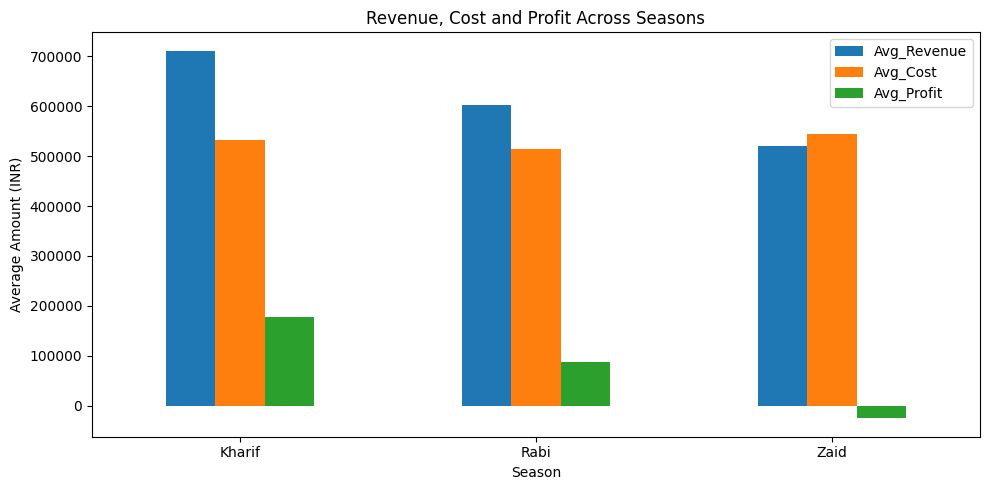

In [11]:
# Economic performance across seasons

economic_summary = df.groupby("Season").agg(
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).round(2)

print("Economic Performance by Season:")
display(economic_summary)

# Profit margin
economic_summary["Profit_Margin_%"] = (
    economic_summary["Avg_Profit"] / economic_summary["Avg_Revenue"] * 100
).round(2)

print("\nProfit Margin by Season:")
display(economic_summary[["Avg_Profit", "Profit_Margin_%"]])

# Revenue, cost and profit comparison
economic_summary[["Avg_Revenue", "Avg_Cost", "Avg_Profit"]].plot(
    kind="bar", figsize=(10, 5)
)

plt.title("Revenue, Cost and Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## Economic Performance: Key Findings

Economic outcomes show a clear seasonal gradient. Kharif records the highest average revenue and profit, with a profit margin of 25.17%. Rabi remains profitable but has a substantially lower profit margin of 14.58%.

Zaid shows the weakest economic performance, where the average cost exceeds average revenue, resulting in a negative average profit of ₹24,804.82 and a negative profit margin of 4.78%.

The results indicate that seasonal variation affects not only agricultural productivity but also the financial sustainability of farming activities. The consistently weaker economic performance of Zaid, together with its lower yield and water-use efficiency, identifies it as the key season requiring further attention in agricultural planning.

In [12]:
from scipy.stats import kruskal

# Create a cleaned copy
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Handle missing numerical values using season-wise median
impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in impute_cols:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())
print("Remaining duplicate rows:", df_clean.duplicated().sum())

# Statistical test for seasonal differences
test_metrics = {
    "Yield": "Yield_Tonnes_Ha",
    "Profit": "Profit_INR",
    "Water Efficiency": "Water_Efficiency_t_per_1000m3",
    "Disease/Pest Risk": "Disease_Pest_Risk_pct"
}

results = []

for name, col in test_metrics.items():
    groups = [
        df_clean[df_clean["Season"] == season][col]
        for season in ["Kharif", "Rabi", "Zaid"]
    ]

    statistic, p_value = kruskal(*groups)

    results.append({
        "Metric": name,
        "Kruskal-Wallis Statistic": round(statistic, 3),
        "p-value": round(p_value, 5),
        "Significant Difference": "Yes" if p_value < 0.05 else "No"
    })

statistical_results = pd.DataFrame(results)
display(statistical_results)

Original shape: (4000, 28)
Cleaned shape: (4000, 28)
Remaining missing values: 0
Remaining duplicate rows: 0


,Metric,Kruskal-Wallis Statistic,p-value,Significant Difference
0,Yield,70.166,0.0,Yes
1,Profit,101.926,0.0,Yes
2,Water Efficiency,56.811,0.0,Yes
3,Disease/Pest Risk,1430.910,0.0,Yes


## Statistical Validation of Seasonal Differences

The Kruskal–Wallis test was applied to statistically evaluate differences across the three seasons. The results show statistically significant seasonal differences in all four examined metrics: yield (H = 70.166), profit (H = 101.926), water-use efficiency (H = 56.811), and disease/pest risk (H = 1430.910), with p < 0.001 in each case.

These results provide statistical support for the seasonal patterns observed during exploratory analysis. Therefore, the differences in agricultural performance, economic outcomes, resource efficiency, and disease/pest risk across seasons are unlikely to be attributable to random variation alone.

The dataset was also successfully prepared for analysis, with duplicate records removed and missing values addressed using season-wise median imputation. The cleaned dataset contains 4,000 records with no remaining missing values or duplicate rows.

# Conclusion

The analysis reveals clear and statistically significant seasonal differences in agricultural performance. Kharif consistently demonstrates the strongest overall performance, with the highest average yield, production, revenue, profit, and water-use efficiency. Rabi shows moderate performance, while Zaid records the weakest outcomes, including negative average profitability.

Environmental conditions vary considerably across seasons; however, rainfall, temperature, soil moisture, and sunlight show very weak linear relationships with yield. This indicates that seasonal agricultural performance cannot be explained by individual environmental factors alone.

The crop-wise analysis shows that the decline in yield from Kharif to Rabi to Zaid is consistent across all examined crops. Economic performance follows the same broad pattern, although profitability varies substantially between crops and regions.

Statistical validation using the Kruskal–Wallis test confirms significant seasonal differences in yield, profit, water-use efficiency, and disease/pest risk (p < 0.001 for all four metrics).

Overall, the findings highlight the importance of season-specific planning, efficient resource utilization, appropriate crop selection, and region-specific agricultural strategies.

# Data-Driven Recommendations

1. **Adopt season-specific planning:** Develop agricultural strategies according to the distinct performance characteristics of Kharif, Rabi, and Zaid rather than applying a uniform approach.

2. **Improve Zaid resource efficiency:** Focus on reducing water consumption and improving water-use efficiency, particularly because Zaid combines high water usage with lower yield and negative average profitability.

3. **Prioritize economically viable crops:** Consider crop-level profitability when selecting crops for different seasons, with greater attention to crops demonstrating consistently positive returns.

4. **Strengthen regional strategies:** Account for regional differences when planning seasonal cultivation, particularly where profitability varies substantially across states.

5. **Integrate multiple factors:** Agricultural decisions should consider environmental conditions, crop characteristics, farming practices, resource utilization, and economic outcomes together rather than relying on a single indicator.

6. **Monitor seasonal risks:** The significant variation in disease and pest risk highlights the need for season-specific risk monitoring and management strategies.